# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Басараб Дмитрій'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-32'      # напр. 'КН-31'
ВАРІАНТ = 1     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Басараб Дмитрій, ШІ-32, варіант 1
ваш потік:                   P>50
ваша пара для графіка 3:     швидкість вітру та потік P>10
ваш агрегат для етапу 4:     медіана
ваше додаткове питання:      Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
data = pd.read_excel(ФАЙЛ)
df = pd.DataFrame(data)

df

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7220,NaN,2017,9,21,2335,58017,84900,21.9,0.361,0.202,0.084,0.0717,0.0475,143000,32900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7221,NaN,2017,9,21,2340,58017,85200,14.1,0.343,0.309,0.118,0.0679,0.0328,143000,32100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7222,NaN,2017,9,21,2345,58017,85500,27.1,0.465,0.237,0.106,0.0593,0.0251,140000,32500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7223,NaN,2017,9,21,2350,58017,85800,23.7,0.36,0.205,0.127,0.091,0.0363,140000,32700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** тому що таблиця містить перші рядки як метадані, через це збилися типи даних стовбців і рядків, збилися і назви 

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
RAW = pd.DataFrame(pd.read_excel(ФАЙЛ, header=None))
RAW.shape
RAW.head(30)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
# ВАШ КОД
RAW.notna().sum()

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** 3 таблиці, перша займає 2-14 стовбці, 2 займає 16-19 стовбці, 3 займає 24-31 стовбці.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:

print("A","|",RAW.iloc[18,1],"|",RAW.iloc[16,1],"  ",RAW.iloc[17,1])
print("B","|",RAW.iloc[18,16],"|",RAW.iloc[26,19])
print("C","|",RAW.iloc[2,26],"|",RAW.iloc[4,26],"  ",RAW.iloc[5,26])

A | # Source: GOES-15 | # Units: Particles = Protons/cm2-s-sr    # Units: Electrons = Electrons/cm2-s-sr
B | #  Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center | Radio Flux 10.7
C | SOHO CELIAS Proton Monitor | Proton speed [km/sec]    Proton density [protons per cubic centimeter]


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | GOES-15 | Protons/cm2-s-sr,Electrons/cm2-s-sr |
| B | U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center | Radio Flux 10.7 |
| C | SOHO CELIAS Proton Monitor | km/sec,protons per cubic centimeter |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
A = RAW.iloc[26:7226, 1:15].copy().reset_index(drop=True)
A.columns = ['YYYY', 'MM', 'DD', 'hhmm', 'Modified_Julian_Day', 'Seconds_of_the_day', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8','E>2.0']

B = RAW.iloc[27:52, 16:20].copy().reset_index(drop=True)
B.columns = ['YYYY', 'MM', 'DD', 'F10.7']

C = RAW.iloc[27:628, 26:32].copy().reset_index(drop=True)
C.columns = ['YYYY', 'MM', 'DD', 'hh', 'speed', 'density']


for df in [A, B, C]:
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(A)
print(B)
print(C)


      YYYY  MM  DD  hhmm  Modified_Julian_Day  Seconds_of_the_day    P>1    P>5   P>10    P>30    P>50   P>100     E>0.8    E>2.0
0     2017   8  28     0                57993                   0  12.00  0.260  0.180  0.1140  0.1040  0.0793   23600.0   1180.0
1     2017   8  28     5                57993                 300  19.40  0.690  0.314  0.1120  0.0612  0.0251   23100.0   1160.0
2     2017   8  28    10                57993                 600   8.48  0.168  0.130  0.0717  0.0614  0.0304   22200.0   1090.0
3     2017   8  28    15                57993                 900  15.40  0.566  0.198  0.0926  0.0568  0.0251   20400.0    997.0
4     2017   8  28    20                57993                1200   6.41  0.156  0.118  0.0597  0.0494  0.0251   18500.0    875.0
...    ...  ..  ..   ...                  ...                 ...    ...    ...    ...     ...     ...     ...       ...      ...
7195  2017   9  21  2335                58017               84900  21.90  0.361  0.202  0.

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
hoursA = A['hhmm'] //100
minsA = A['hhmm'] % 100
A['ts'] = pd.to_datetime({
    'year': A['YYYY'],
    'month': A['MM'],
    'day': A['DD'],
    'hour': hoursA,
    'minute':minsA
})

B['ts'] = pd.to_datetime({
    'year': B['YYYY'],
    'month': B['MM'],
    'day': B['DD'],
})


C['ts'] = pd.to_datetime({
    'year': C['YYYY'] +2000,
    'month': C['MM'],
    'day': C['DD'],
    'hour': C['hh']
})
A

,YYYY,MM,DD,hhmm,Modified_Julian_Day,Seconds_of_the_day,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
0,2017,8,28,0,57993,0,12.00,0.260,0.180,0.1140,0.1040,0.0793,23600.0,1180.0,2017-08-28 00:00:00
1,2017,8,28,5,57993,300,19.40,0.690,0.314,0.1120,0.0612,0.0251,23100.0,1160.0,2017-08-28 00:05:00
2,2017,8,28,10,57993,600,8.48,0.168,0.130,0.0717,0.0614,0.0304,22200.0,1090.0,2017-08-28 00:10:00
3,2017,8,28,15,57993,900,15.40,0.566,0.198,0.0926,0.0568,0.0251,20400.0,997.0,2017-08-28 00:15:00
4,2017,8,28,20,57993,1200,6.41,0.156,0.118,0.0597,0.0494,0.0251,18500.0,875.0,2017-08-28 00:20:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2017,9,21,2335,58017,84900,21.90,0.361,0.202,0.0840,0.0717,0.0475,143000.0,32900.0,2017-09-21 23:35:00
7196,2017,9,21,2340,58017,85200,14.10,0.343,0.309,0.1180,0.0679,0.0328,143000.0,32100.0,2017-09-21 23:40:00
7197,2017,9,21,2345,58017,85500,27.10,0.465,0.237,0.1060,0.0593,0.0251,140000.0,32500.0,2017-09-21 23:45:00
7198,2017,9,21,2350,58017,85800,23.70,0.360,0.205,0.1270,0.0910,0.0363,140000.0,32700.0,2017-09-21 23:50:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
# ВАШ КОД
print(A.describe())
print(B.describe())
print(C.describe())


         YYYY           MM           DD         hhmm  Modified_Julian_Day  Seconds_of_the_day           P>1          P>5         P>10         P>30         P>50       P>100          E>0.8  \
count  7200.0  7200.000000  7200.000000  7200.000000          7200.000000         7200.000000   7197.000000  7197.000000  7197.000000  7197.000000  7197.000000  7197.00000    7197.000000   
mean   2017.0     8.840000    13.960000  1177.500000         58005.000000        43050.000000    689.325064   156.626057    76.474020    18.838604     7.446840     1.65929   81862.741801   
min    2017.0     8.000000     1.000000     0.000000         57993.000000            0.000000      0.429000     0.151000     0.117000     0.057600     0.045500     0.02240       4.300000   
25%    2017.0     9.000000     7.000000   588.750000         57999.000000        21525.000000     11.700000     0.279000     0.186000     0.098400     0.059700     0.02630   22200.000000   
50%    2017.0     9.000000    13.000000  1177.5000

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
print(C[['speed','density']].agg(['mean', 'min']))
neg_speed = (C['speed'] < 0).sum()
neg_density = (C['density'] < 0).sum()
print(neg_speed,neg_density)

Cnew = C.loc[C['speed'] < 0, 'speed'] = np.nan
Cnew = C.loc[C['density'] < 0, 'density'] = np.nan

print(C[['speed','density']].agg(['mean', 'min']))



           speed   density
mean  506.547421  2.907654
min    -1.000000 -1.000000
8 8
           speed   density
mean  513.394604  2.960371
min   277.000000  0.100000


**Відповідь 3.2: це значення коли швидкість і густину не зафіксували, їх 8, середнє і мінімум спотворювали відємними значеннями їх не треба враховувати**

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

**Відповідь 3.3:** я думаю шо безглуздими є середнє значення років днів ітд. 

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [13]:
# ВАШ КОД

At = A.resample("h",on='ts').mean().copy()
a = At.agg(['mean','max'])
Bt = B.set_index('ts').resample('1h').ffill()
print(a)


        YYYY    MM     DD    hhmm  Modified_Julian_Day  Seconds_of_the_day           P>1          P>5         P>10        P>30        P>50      P>100          E>0.8          E>2.0
mean  2017.0  8.84  13.96  1177.5              58005.0             43050.0    689.154356   156.589812    76.454218   18.831273    7.443857   1.658624   81842.468184   11397.048492
max   2017.0  9.00  31.00  2327.5              58017.0             84450.0  15908.333333  2306.666667  1243.333333  387.083333  180.833333  52.933333  253916.666667  106916.666667


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

                        max   median
ts                                  
2017-08-28 00:00:00  0.1780  0.06130
2017-08-28 01:00:00  0.0798  0.05315
2017-08-28 02:00:00  0.1110  0.06275
2017-08-28 03:00:00  0.1390  0.05795
2017-08-28 04:00:00  0.1420  0.06155
2017-08-28 05:00:00  0.0932  0.05565
2017-08-28 06:00:00  0.1060  0.06700
2017-08-28 07:00:00  0.1550  0.06350
2017-08-28 08:00:00  0.1380  0.07270
2017-08-28 09:00:00  0.1090  0.07570
2017-08-28 10:00:00  0.1060  0.06100
2017-08-28 11:00:00  0.1020  0.05575
2017-08-28 12:00:00  0.0962  0.06965
2017-08-28 13:00:00  0.0892  0.05430
2017-08-28 14:00:00  0.1840  0.07980
2017-08-28 15:00:00  0.1430  0.05785
2017-08-28 16:00:00  0.1250  0.07425
2017-08-28 17:00:00  0.1450  0.07600
2017-08-28 18:00:00  0.1610  0.05700
2017-08-28 19:00:00  0.1210  0.06500
2017-08-28 20:00:00  0.0683  0.05155
2017-08-28 21:00:00  0.1330  0.07890
2017-08-28 22:00:00  0.1260  0.06375
2017-08-28 23:00:00  0.1210  0.08165


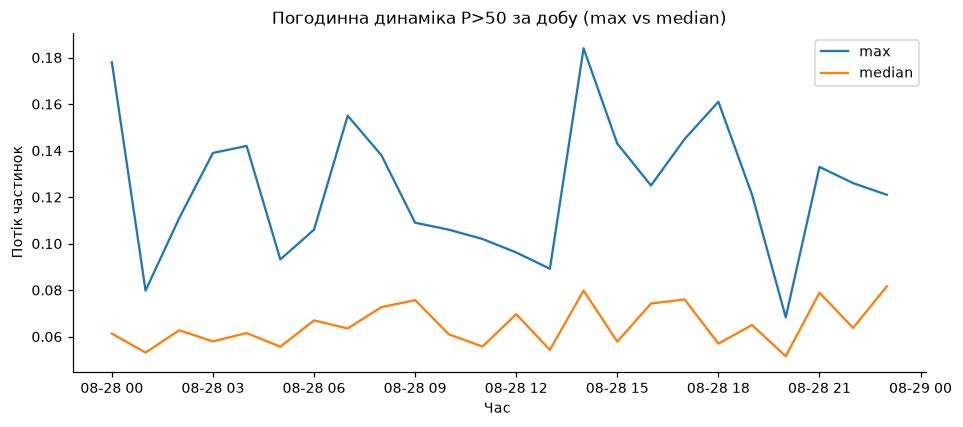

In [14]:
A_dob = A.set_index('ts').loc['2017-08-28':'2017-08-28']

p50_hourly = A_dob['P>50'].resample('1h').agg(['max', 'median'])
print(p50_hourly)
plt.figure(figsize=(10, 4))
plt.plot(p50_hourly.index, p50_hourly['max'], label='max')
plt.plot(p50_hourly.index, p50_hourly['median'], label='median')

plt.title('Погодинна динаміка P>50 за добу (max vs median)')
plt.xlabel('Час ')
plt.ylabel('Потік частинок')

plt.legend()

plt.show()

**Відповідь 4.2:** криві повторюють зростання та спадання, але відрізняються амплітудою. Різниця між ними стане суттєвою при різкому сплеску максимального значення.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [15]:
# ВАШ КОД
type = 'outer'


M = pd.merge(At,Bt.reset_index()[['ts','F10.7']],on='ts',how=type).merge(C[['ts','speed','density']],on='ts',how=type)
M


,ts,YYYY,MM,DD,hhmm,Modified_Julian_Day,Seconds_of_the_day,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,F10.7,speed,density
0,2017-08-28 00:00:00,2017.0,8.0,28.0,27.5,57993.0,1650.0,9.778333,0.324917,0.192917,0.098850,0.077583,0.040692,20941.666667,1011.583333,82.0,285.0,3.0
1,2017-08-28 01:00:00,2017.0,8.0,28.0,127.5,57993.0,5250.0,7.994167,0.291667,0.156583,0.072583,0.058700,0.029950,18091.666667,713.000000,82.0,305.0,3.4
2,2017-08-28 02:00:00,2017.0,8.0,28.0,227.5,57993.0,8850.0,6.099167,0.283000,0.177667,0.084450,0.069642,0.035025,14108.333333,380.833333,82.0,309.0,1.7
3,2017-08-28 03:00:00,2017.0,8.0,28.0,327.5,57993.0,12450.0,4.752500,0.236833,0.166333,0.087658,0.068092,0.035517,12766.666667,267.916667,82.0,304.0,2.0
4,2017-08-28 04:00:00,2017.0,8.0,28.0,427.5,57993.0,16050.0,4.158333,0.334917,0.208333,0.084800,0.072850,0.039708,11333.333333,203.000000,82.0,302.0,2.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596,2017-09-21 20:00:00,2017.0,9.0,21.0,2027.5,58017.0,73650.0,42.102500,0.397500,0.226833,0.089325,0.069983,0.039692,178750.000000,63175.000000,NaN,379.0,1.8
597,2017-09-21 21:00:00,2017.0,9.0,21.0,2127.5,58017.0,77250.0,50.783333,0.489250,0.317583,0.121358,0.077467,0.033417,175833.333333,58350.000000,NaN,380.0,1.8
598,2017-09-21 22:00:00,2017.0,9.0,21.0,2227.5,58017.0,80850.0,39.000000,0.350000,0.200250,0.094358,0.070633,0.039600,167750.000000,49366.666667,NaN,387.0,1.1
599,2017-09-21 23:00:00,2017.0,9.0,21.0,2327.5,58017.0,84450.0,28.825000,0.465000,0.257833,0.113575,0.078108,0.045125,150083.333333,37525.000000,NaN,380.0,1.0


**Відповідь 4.3:** погодинне A 600
погодинне B 577 рядок
погодинне C 601 рядок
тип inner дає 577 рядків тому що B має найменше рядків, іннер зєднує тільки ті рядки де є всі дані без пропусків
тип outer дає 601 рядків тому що включає всі рядки і якшо нема даних для певного часу то ставить NaN

Вибрано outer щоб не втрачати всі дані якшо в якість таблиці їх нема.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [16]:
# ВАШ КОД
def group(val):
    if val < 10:
        return 'тиха'
    elif val < 1000:
        return 'активна'
    else:
        return 'дуже активна'
M['група'] = [group(i) for i in M['P>10']]

M

,ts,YYYY,MM,DD,hhmm,Modified_Julian_Day,Seconds_of_the_day,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,F10.7,speed,density,група
0,2017-08-28 00:00:00,2017.0,8.0,28.0,27.5,57993.0,1650.0,9.778333,0.324917,0.192917,0.098850,0.077583,0.040692,20941.666667,1011.583333,82.0,285.0,3.0,тиха
1,2017-08-28 01:00:00,2017.0,8.0,28.0,127.5,57993.0,5250.0,7.994167,0.291667,0.156583,0.072583,0.058700,0.029950,18091.666667,713.000000,82.0,305.0,3.4,тиха
2,2017-08-28 02:00:00,2017.0,8.0,28.0,227.5,57993.0,8850.0,6.099167,0.283000,0.177667,0.084450,0.069642,0.035025,14108.333333,380.833333,82.0,309.0,1.7,тиха
3,2017-08-28 03:00:00,2017.0,8.0,28.0,327.5,57993.0,12450.0,4.752500,0.236833,0.166333,0.087658,0.068092,0.035517,12766.666667,267.916667,82.0,304.0,2.0,тиха
4,2017-08-28 04:00:00,2017.0,8.0,28.0,427.5,57993.0,16050.0,4.158333,0.334917,0.208333,0.084800,0.072850,0.039708,11333.333333,203.000000,82.0,302.0,2.3,тиха
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596,2017-09-21 20:00:00,2017.0,9.0,21.0,2027.5,58017.0,73650.0,42.102500,0.397500,0.226833,0.089325,0.069983,0.039692,178750.000000,63175.000000,NaN,379.0,1.8,тиха
597,2017-09-21 21:00:00,2017.0,9.0,21.0,2127.5,58017.0,77250.0,50.783333,0.489250,0.317583,0.121358,0.077467,0.033417,175833.333333,58350.000000,NaN,380.0,1.8,тиха
598,2017-09-21 22:00:00,2017.0,9.0,21.0,2227.5,58017.0,80850.0,39.000000,0.350000,0.200250,0.094358,0.070633,0.039600,167750.000000,49366.666667,NaN,387.0,1.1,тиха
599,2017-09-21 23:00:00,2017.0,9.0,21.0,2327.5,58017.0,84450.0,28.825000,0.465000,0.257833,0.113575,0.078108,0.045125,150083.333333,37525.000000,NaN,380.0,1.0,тиха


**Самоперевірка етапу 4.**

In [17]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

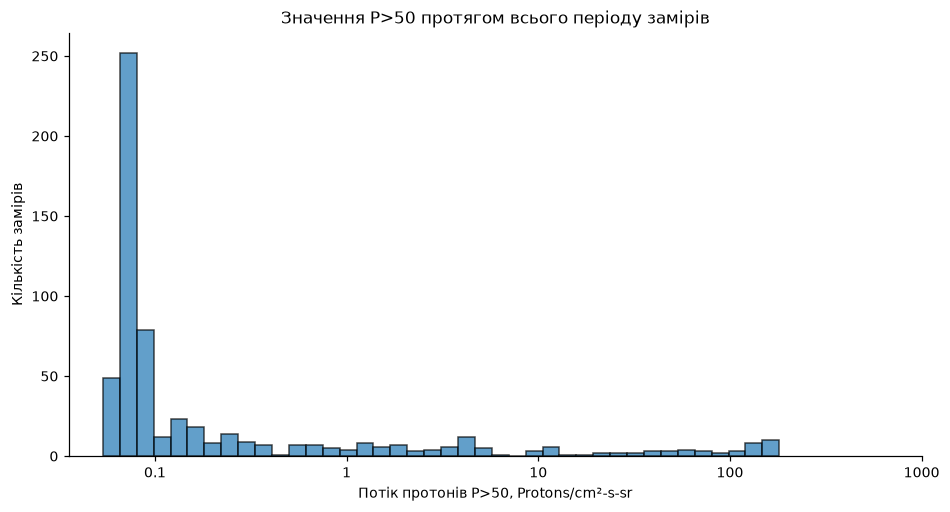

In [18]:
import numpy as np
import matplotlib.pyplot as plt


df = M
p50_clean = df['P>50'].dropna()


plt.figure(figsize=(10, 5))
plt.hist(np.log10(p50_clean), bins=40, edgecolor='black', alpha=0.7)

ticks = [-1, 0, 1, 2, 3]
labels = ['0.1', '1', '10', '100', '1000']
plt.xticks(ticks, labels)


plt.title("Значення P>50 протягом всього періоду замірів")
plt.xlabel("Потік протонів P>50, Protons/cm²-s-sr")  
plt.ylabel("Кількість замірів")                        

plt.show()

**Висновок:** більшість часу потік протонів знаходиться в спокійному стані, але деколи він збільшується і може зростати до 100 чи навіть 1000 разів.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

[0      285.0
1      305.0
2      309.0
3      304.0
4      302.0
       ...  
595    394.0
596    379.0
597    380.0
598    387.0
599    380.0
Name: speed, Length: 408, dtype: float64, 193    583.0
194    576.0
195    577.0
196    570.0
197    558.0
       ...  
420    448.0
421    448.0
422    457.0
423    469.0
424    484.0
Name: speed, Length: 167, dtype: float64, 334    552.0
336    566.0
337    575.0
338    564.0
339    557.0
340    556.0
341    556.0
342    558.0
343    556.0
344    554.0
345    555.0
346    556.0
347    556.0
348    555.0
349    555.0
350    556.0
351    557.0
600    381.0
Name: speed, dtype: float64]


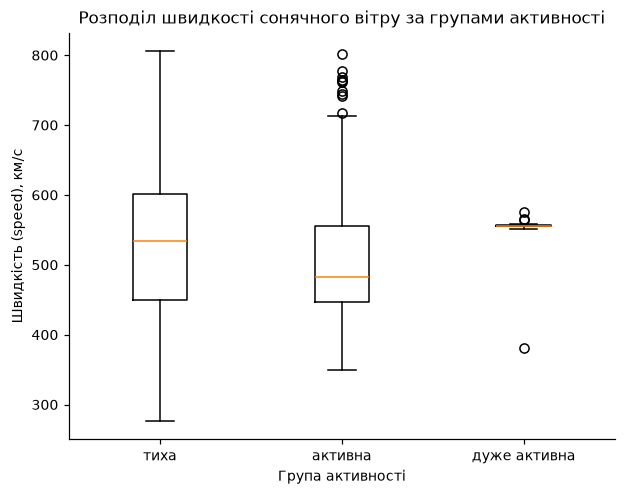

In [19]:
# ВАШ КОД

df = M
groups = df['група'].unique()
df = [df[df['група'] == g]['speed'].dropna() for g in groups]
print(df)

plt.figure()
plt.boxplot(df, tick_labels=groups)

plt.title('Розподіл швидкості сонячного вітру за групами активності')
plt.xlabel('Група активності')
plt.ylabel('Швидкість (speed), км/с')

plt.show()

**Висновок:** boxplot показує крайніми межами нормальні дані поза центральними 50%, прямокутник центральні 50%, оранджева лінія медіану, а точки це аномальні значення.
Гоафік показує шо тиха група має високу варіативність швидкостей, вона рівномірна. В активній групі переважають вищі швидкості, є навіть аномально високі. Найактивніша група має невеликий розмах у швидкостях, але зустрічаються аномально високі або низькі швидкості протонів. 

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

коефіцієнт кореляції:  0.07096067649918358


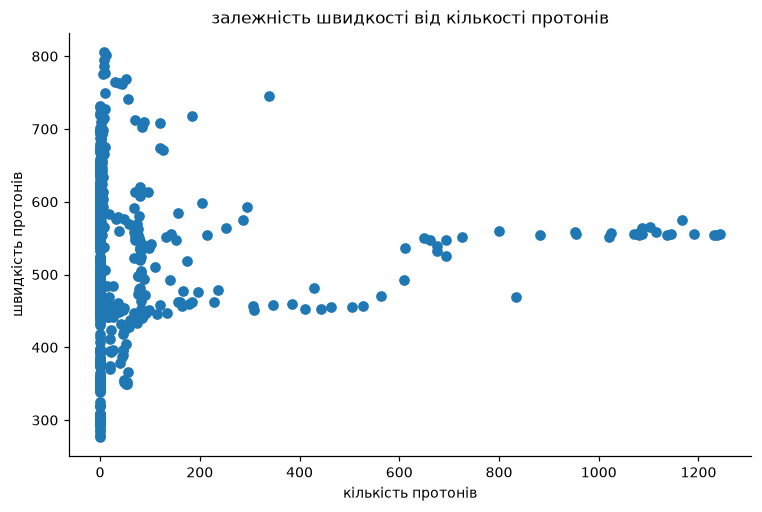

In [20]:
# ВАШ КОД
df = M

df = M[['speed', 'P>10']]

plt.figure(figsize=(8, 5))

plt.scatter(df['P>10'], df['speed'])
plt.title("залежність швидкості від кількості протонів")
plt.xlabel("кількість протонів")
plt.ylabel("швидкість протонів")

coef = df['P>10'].corr(df['speed'])
print("коефіцієнт кореляції: ",coef)


**Висновок:**графік показує що більшість вимірів має низькі значення кількості протонів, і їхня швидкість дуже різниться.В той час високі значення кількості протонів тримаються в межах 400-600 км/c. Звязку між цими величинами майже нема.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

          група         ts  YYYY   MM   DD  hhmm  Modified_Julian_Day  Seconds_of_the_day  P>1  P>5  P>10  P>30  P>50  P>100  E>0.8  E>2.0  F10.7  speed  density
0       активна  27.787022   167  167  167   167                  167                 167  167  167   167   167   167    167    167    167    167    167      167
1  дуже активна   2.828619    17   17   17    17                   17                  17   17   17    17    17    17     17     17     17     17     18       18
2          тиха  69.217970   416  416  416   416                  416                 416  416  416   416   416   416    416    416    416    393    408      408


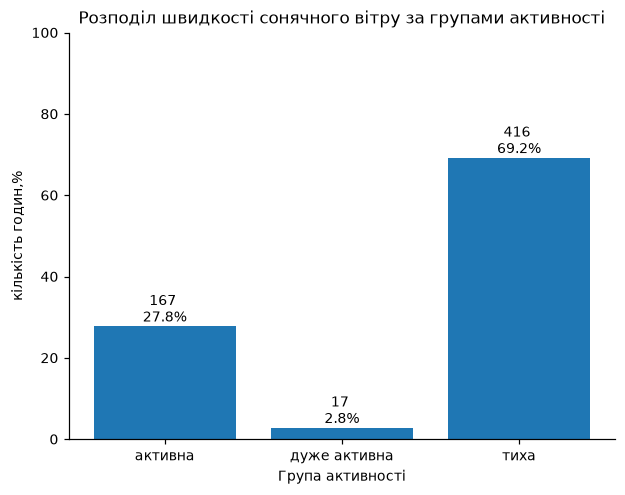

In [21]:


df = M

df = df.groupby('група').count().reset_index()

count = df['ts'].sum()
df['ts'] = df['P>50']/count*100
print(df)
bars = plt.bar(df['група'],df['ts'])
labels = [f"{round(coun)} \n{pers:.1f}%" for pers, coun in zip(df['ts'],df['ts']*count/100)]
plt.bar_label(bars,labels=labels)
plt.ylim(0,100)
plt.title('Розподіл швидкості сонячного вітру за групами активності')
plt.xlabel('Група активності')
plt.ylabel('кількість годин,%')

plt.show()

**Висновок:** найбільше потоків вважаються тихими, а найменше - дуже активними.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

         P>10                  ts
0    0.192917 2017-08-28 00:00:00
1    0.156583 2017-08-28 01:00:00
2    0.177667 2017-08-28 02:00:00
3    0.166333 2017-08-28 03:00:00
4    0.208333 2017-08-28 04:00:00
..        ...                 ...
595  0.229833 2017-09-21 19:00:00
596  0.226833 2017-09-21 20:00:00
597  0.317583 2017-09-21 21:00:00
598  0.200250 2017-09-21 22:00:00
599  0.257833 2017-09-21 23:00:00

[600 rows x 2 columns]


Text(0, 0.5, 'кількість протонів')

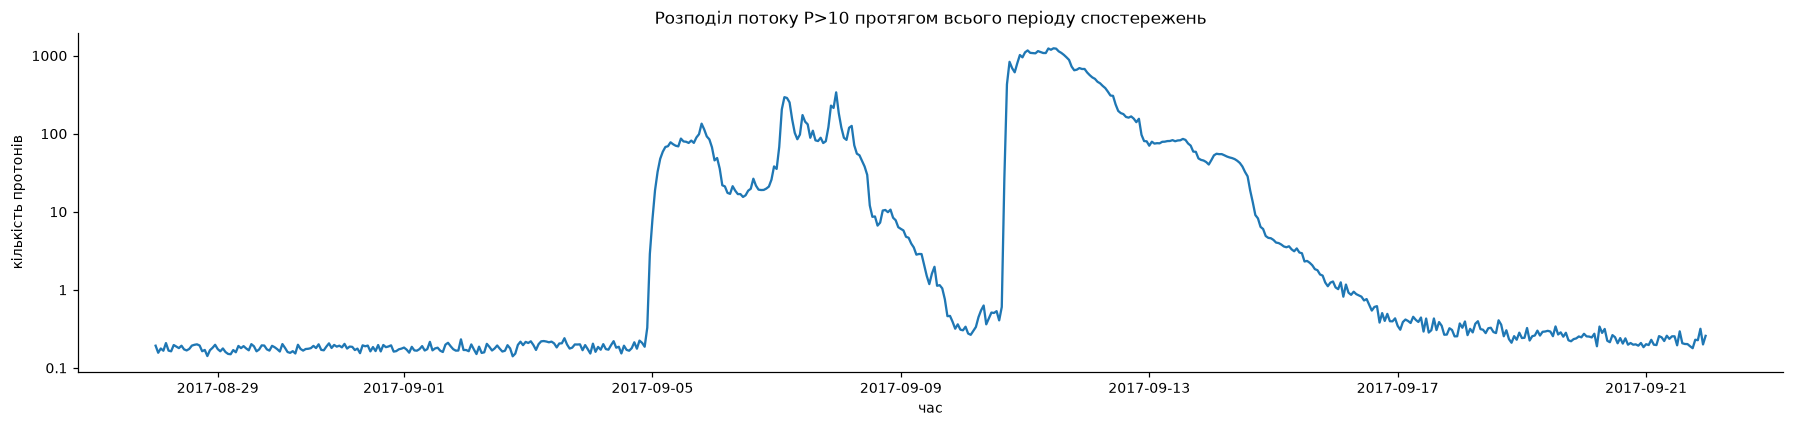

In [22]:
# ВАШ КОД
df = M[['P>10','ts']].dropna()
print(df)
plt.figure(figsize=(20,4))
plt.plot(df['ts'],np.log10(df['P>10']))
ticks = [-1, 0, 1, 2, 3]
labels = ['0.1', '1', '10', '100', '1000']
plt.yticks(ticks,labels)

plt.title('Розподіл потоку P>10 протягом всього періоду спостережень')
plt.xlabel('час')
plt.ylabel('кількість протонів')

**Висновок:** протягом першого тижня спостережень значення коливаються в межах 0.3 протони/см2-s-sr, потім різко піднімаючись два рази протягом 2 тижнів до 10000 разів, поступово спадаючи до 0.5 протонів/см2-s-sr

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

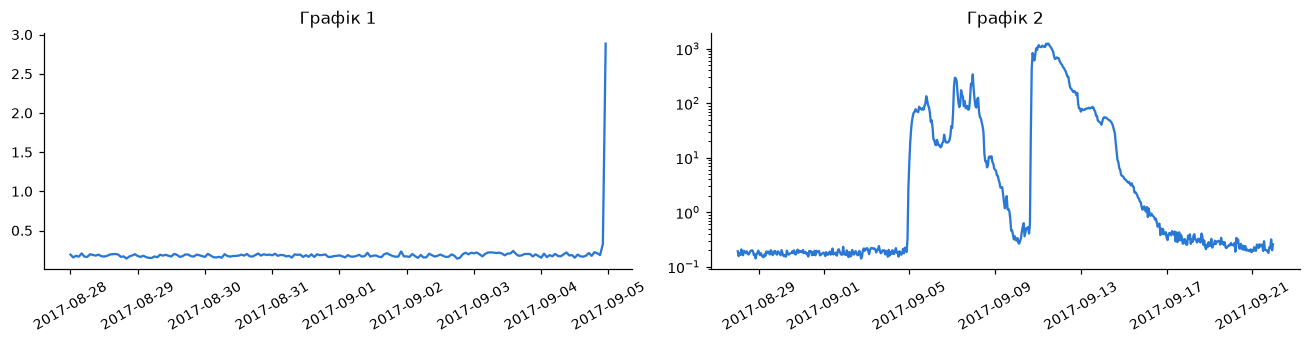

In [23]:
СТОВПЕЦЬ = 'P>10'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка:  досить стабільна протягом тижня, в кінці відбувся дуже значне погіршення
2. Висновок з другого графіка: протягом місяця погода була нестабільна з різкими погіршеннями і покращеннями
3. Дві відмінності між ними: дані взяті за різний проміжок часу, в одному погода стабільна але не враховуються інші заміри


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

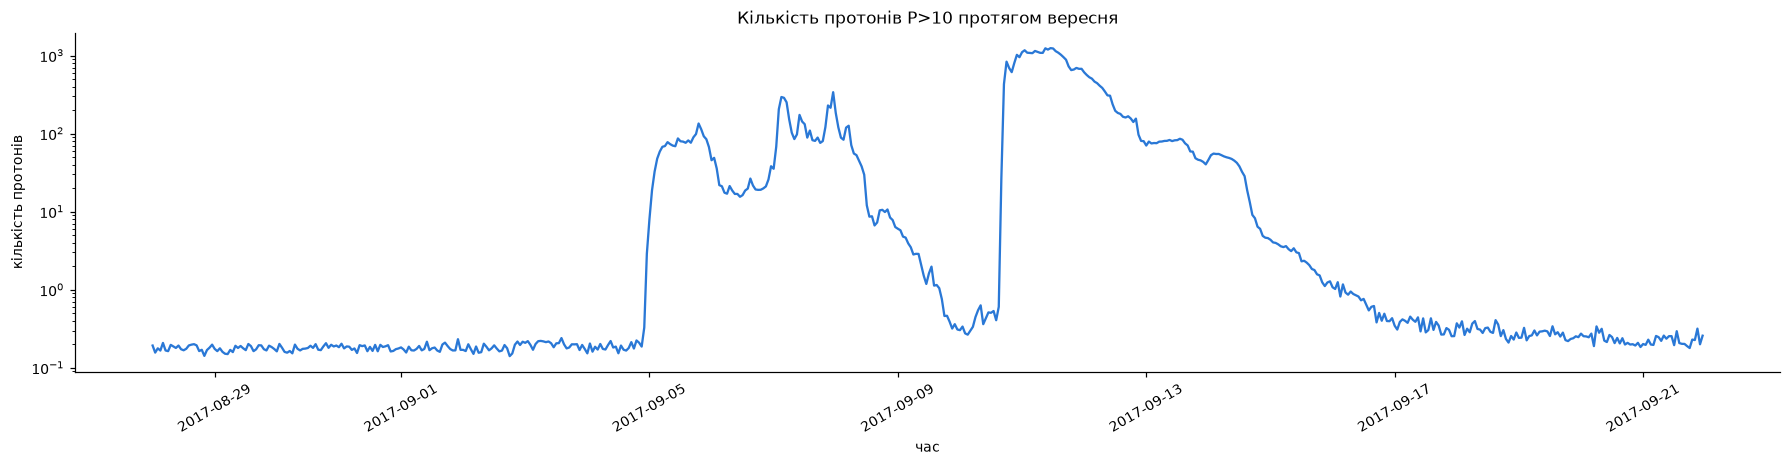

In [24]:
# ВАШ КОД
plt.figure(figsize=(20,4))
plt.plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
plt.yscale('log')
plt.title('Кількість протонів P>10 протягом вересня')
plt.xlabel("час")
plt.ylabel("кількість протонів")
plt.tick_params(axis='x', rotation=30)

**Відповідь 6.2:** Графік 2 цілком описує стан погоди, але я додав підписи щоб було зрозуміліще шо описує графік.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** з графіка 5.2 видно що чим активніша група протонів, тим стабільнішою є їхня швидкість, при чому медіани значень відрізняються до 100 км/c.

**Спостереження 2:** графік 5.3 показує що більшість вимірів має низькі значення кількості протонів, і їхня швидкість дуже різниться.В той час високі значення кількості протонів тримаються в межах 400-600 км/c. Звязку між цими величинами майже нема.

**Спостереження 3:** за графіком 6.2 видно що погода може бути стабільною,але якшо вона погіршується це відбувається дуже різко і триває до тижня часу.


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [25]:
# Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?
df = M['група']
max_c = 0
count = 0
for group in df:
    if group == "активна":
        count +=1
        
    else:
        max_c = np.maximum(count,max_c)
        count = 0
max_c

 

np.int64(84)

**Відповідь 7.2:** найдовший цикл активної групи тривав 84 години.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [26]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'ні',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'ні',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'ні',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'допоміг з логарифмуванням, не знав як правильно зробити, перевірив чи певний діапазон має дійсно такі значення, в основному по синтаксу і по переформулюванню питань питав бо не було зрозуміло що вимагають'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [27]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Басараб Дмитрій
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    ні
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    ні
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                ні
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:
допоміг з логарифмуванням, не знав як правильно зробити, перевірив чи певний діапазон має дійсно такі значення, в основному по синтаксу і по переформулюванню питань питав бо не було зрозуміло що вимагають
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [28]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 19)


In [29]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
